In [1]:
import pandas as pd

churn_cust_info = pd.read_excel(
    r"C:\Users\MOI\Downloads\Bank_Churn_Messy.xlsx"
)

churn_cust_info.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1


In [2]:
churn_acct_info = pd.read_excel(
    r"C:\Users\MOI\Downloads\Bank_Churn_Messy.xlsx", sheet_name=1
)

churn_acct_info.head()

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
2,15647311,€83807.86,1,Yes,1,Yes,0
3,15619304,€159660.8,3,No,8,No,1
4,15701354,€0.0,2,No,1,No,0


In [3]:
churn_df = churn_cust_info.merge(churn_acct_info, how="left", on="CustomerId")
churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
1,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,1,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,8,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,1,No,0


In [4]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10004 entries, 0 to 10003
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10004 non-null  int64  
 1   Surname          10001 non-null  object 
 2   CreditScore      10004 non-null  int64  
 3   Geography        10004 non-null  object 
 4   Gender           10004 non-null  object 
 5   Age              10001 non-null  float64
 6   Tenure_x         10004 non-null  int64  
 7   EstimatedSalary  10004 non-null  object 
 8   Balance          10004 non-null  object 
 9   NumOfProducts    10004 non-null  int64  
 10  HasCrCard        10004 non-null  object 
 11  Tenure_y         10004 non-null  int64  
 12  IsActiveMember   10004 non-null  object 
 13  Exited           10004 non-null  int64  
dtypes: float64(1), int64(6), object(7)
memory usage: 1.1+ MB


In [5]:
churn_df = churn_df.drop("Tenure_y", axis=1).rename({"Tenure_x":"Tenure"}, axis=1)
churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,Yes,1
1,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,No,0


In [6]:
churn_df.columns.tolist()

['CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'EstimatedSalary',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'Exited']

In [7]:
churn_df.duplicated().sum()

np.int64(4)

In [8]:
churn_df = churn_df.drop_duplicates()

churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,No,0
5,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1,€125510.82,1,Yes,Yes,0


In [9]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              9997 non-null   float64
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  object 
 8   Balance          10000 non-null  object 
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 1.1+ MB


In [10]:
#churn_df["EstimatedSalary"] = churn_df["EstimatedSalary"].str.replace("€", "").astype("float")
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              9997 non-null   float64
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  object 
 8   Balance          10000 non-null  object 
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 1.1+ MB


In [11]:
churn_df["Balance"] = churn_df["Balance"].str.replace("€", "").astype("float")

churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              9997 non-null   float64
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  object 
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.1+ MB


In [12]:
churn_df[churn_df.isna().any(axis=1) == True]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
29,15728693,NaN,574,Germany,Female,NaN,3,-€999999,141349.43,1,Yes,Yes,0
122,15580203,NaN,674,Spain,Male,NaN,6,-€999999,120193.42,1,No,No,0
9390,15756954,NaN,538,France,Female,NaN,2,-€999999,0.00,1,Yes,Yes,0


In [13]:
churn_df = churn_df.fillna(value={"Surname": "Missing", "Age": churn_df["Age"].median()})
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  float64
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  object 
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  object 
 11  IsActiveMember   10000 non-null  object 
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.1+ MB


In [14]:
churn_df.iloc[[28, 121, 9389]]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
29,15728693,Missing,574,Germany,Female,37.0,3,-€999999,141349.43,1,Yes,Yes,0
122,15580203,Missing,674,Spain,Male,37.0,6,-€999999,120193.42,1,No,No,0
9390,15756954,Missing,538,France,Female,37.0,2,-€999999,0.00,1,Yes,Yes,0


In [15]:
churn_df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921500,5.012800,76485.889288,1.530200,0.203700
std,7.193619e+04,96.653299,10.487552,2.892174,62397.405202,0.581654,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000


In [25]:
churn_df["EstimatedSalary"] = churn_df["EstimatedSalary"].replace(-999999, churn_df["EstimatedSalary"].median())
churn_df.describe()

,CustomerId,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921500,5.012800,100092.265795,76485.889288,1.530200,0.203700
std,7.193619e+04,96.653299,10.487552,2.892174,57510.146430,62397.405202,0.581654,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,11.580000,0.000000,1.000000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,51002.110000,0.000000,1.000000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,100236.020000,97198.540000,1.000000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,149388.247500,127644.240000,2.000000,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,1.000000


In [17]:
(churn_df["EstimatedSalary"] == -999999).sum()

np.int64(0)

In [20]:
churn_df["EstimatedSalary"].dtype

dtype('float64')

In [23]:
median_salary = churn_df.loc[
    churn_df["EstimatedSalary"] != -999999,
    "EstimatedSalary"
].median()

churn_df["EstimatedSalary"] = churn_df["EstimatedSalary"].replace(
    -999999,
    median_salary
)

In [24]:
churn_df.describe()

,CustomerId,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921500,5.012800,100092.265795,76485.889288,1.530200,0.203700
std,7.193619e+04,96.653299,10.487552,2.892174,57510.146430,62397.405202,0.581654,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,11.580000,0.000000,1.000000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,51002.110000,0.000000,1.000000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,100236.020000,97198.540000,1.000000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,149388.247500,127644.240000,2.000000,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,1.000000


In [27]:
churn_df["EstimatedSalary"] = (
    churn_df["EstimatedSalary"]
    .str.replace("€", "", regex=False)
    .str.strip()
    .astype(float)
)

AttributeError: Can only use .str accessor with string values!

In [28]:
churn_df["Geography"].value_counts()

Geography
Germany    2509
Spain      2477
France     1741
French     1655
FRA        1618
Name: count, dtype: int64

In [29]:
import numpy as np
churn_df["Geography"] = np.where(churn_df["Geography"].isin(["FRA", "French", "France"]), "FRANCE", churn_df["Geography"])
churn_df["Geography"].value_counts()

Geography
FRANCE     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

<Axes: xlabel='Exited'>

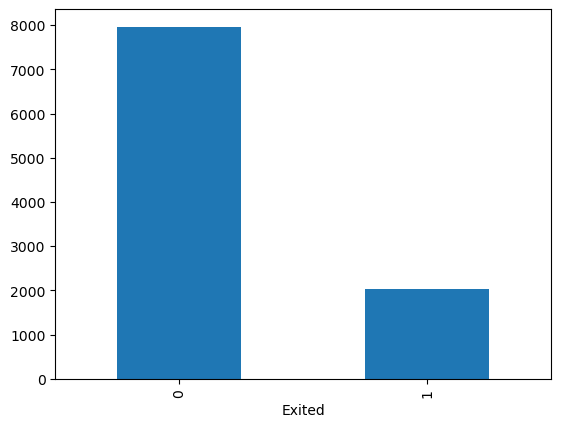

In [30]:
churn_df["Exited"].value_counts().plot.bar()

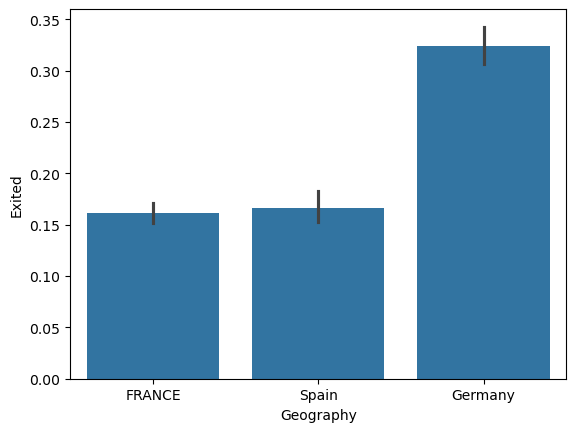

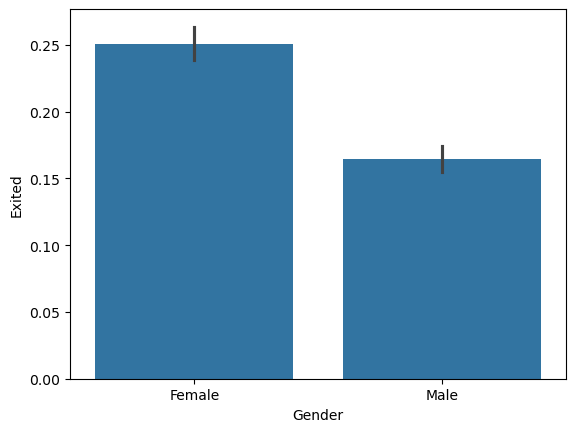

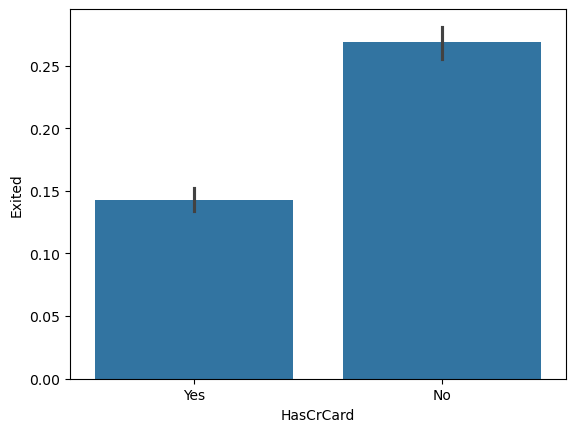

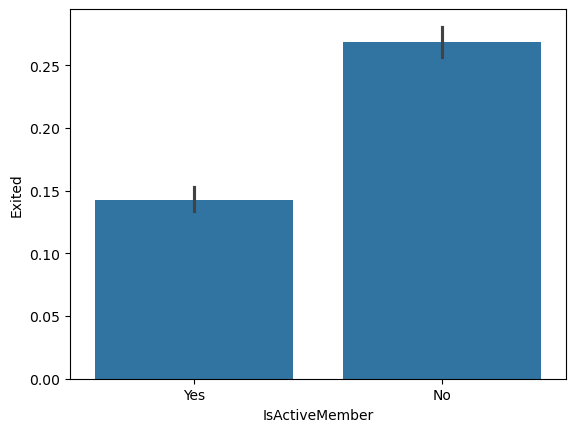

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in churn_df.drop("Surname", axis=1).select_dtypes("object"):
    sns.barplot(data=churn_df, x=col, y="Exited")
    plt.show()

In [32]:
churn_df.select_dtypes("object")

,Surname,Geography,Gender,HasCrCard,IsActiveMember
0,Hargrave,FRANCE,Female,Yes,Yes
2,Hill,Spain,Female,Yes,Yes
3,Onio,FRANCE,Female,No,No
4,Boni,FRANCE,Female,No,No
5,Mitchell,Spain,Female,Yes,Yes
...,...,...,...,...,...
9996,Obijiaku,FRANCE,Male,No,No
9997,Johnstone,FRANCE,Male,Yes,Yes
9998,Liu,FRANCE,Female,Yes,Yes
9999,Sabbatini,Germany,Male,No,No


<Axes: ylabel='Age'>

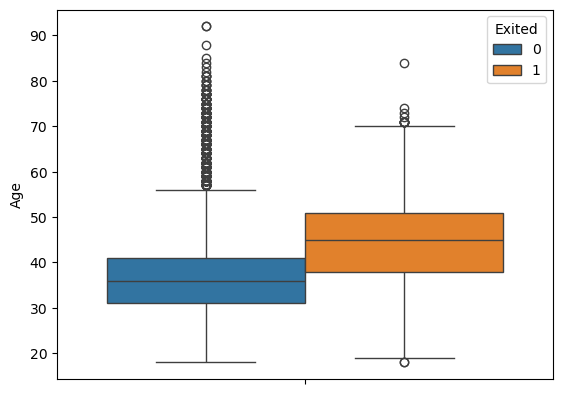

In [33]:
sns.boxplot(data=churn_df, y="Age", hue="Exited")

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

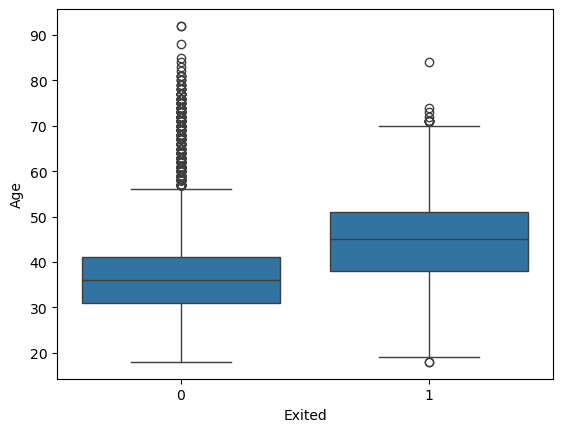

In [36]:
sns.boxplot(data=churn_df, x="Exited", y="Age")
plt.show()

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
churn_cust_info = pd.read_excel(
    r"C:\Users\MOI\Downloads\Bank_Churn_Messy.xlsx"
)

In [39]:
churn_acct_info = pd.read_excel(
    r"C:\Users\MOI\Downloads\Bank_Churn_Messy.xlsx",
    sheet_name=1
)

In [40]:
churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,FRANCE,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0
3,15619304,Onio,502,FRANCE,Female,42.0,8,113931.57,159660.80,3,No,No,1
4,15701354,Boni,699,FRANCE,Female,39.0,1,93826.63,0.00,2,No,No,0
5,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0


In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
churn_cust_info = pd.read_excel(
    r"C:\Users\MOI\Downloads\Bank_Churn_Messy.xlsx"
)

In [43]:
churn_acct_info = pd.read_excel(
    r"C:\Users\MOI\Downloads\Bank_Churn_Messy.xlsx",
    sheet_name=1
)

In [44]:
churn_df = churn_cust_info.merge(
    churn_acct_info,
    how="left",
    on="CustomerId"
)

In [45]:
churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
1,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,1,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,8,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,1,No,0


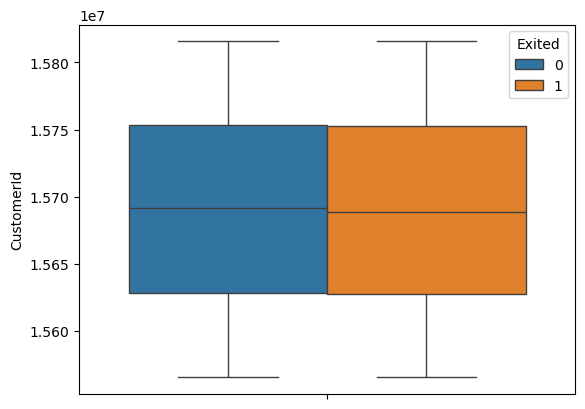

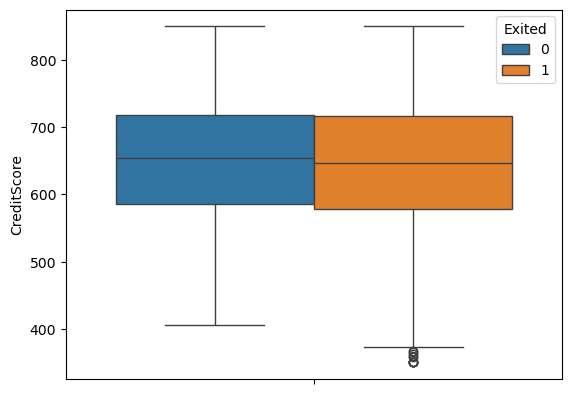

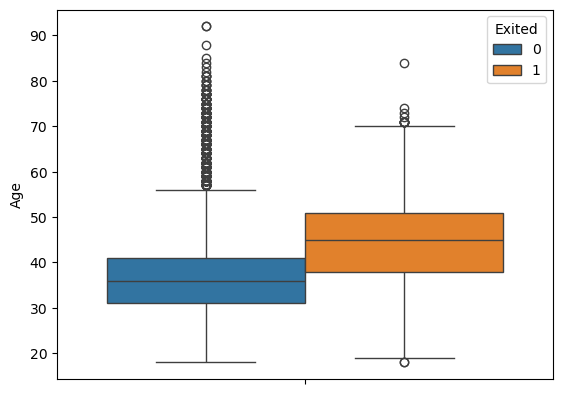

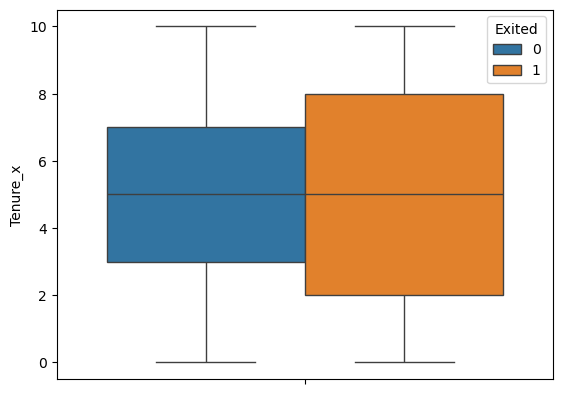

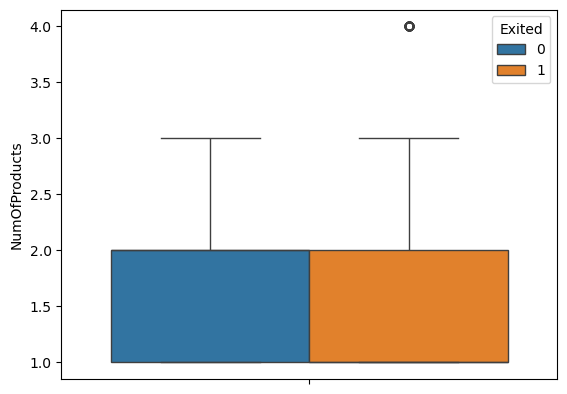

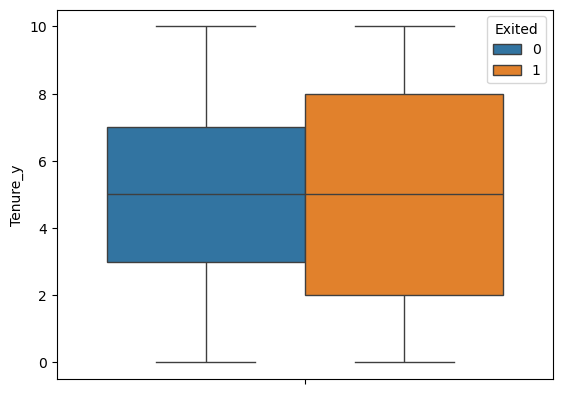

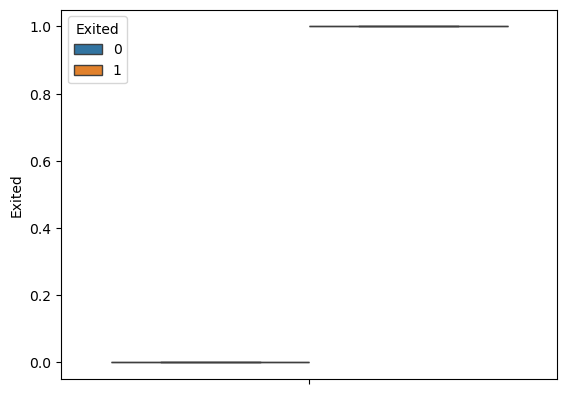

In [46]:
for col in churn_df.drop("Surname", axis=1).select_dtypes("number"):
    sns.boxplot(data=churn_df, y=col, hue="Exited")
    plt.show()

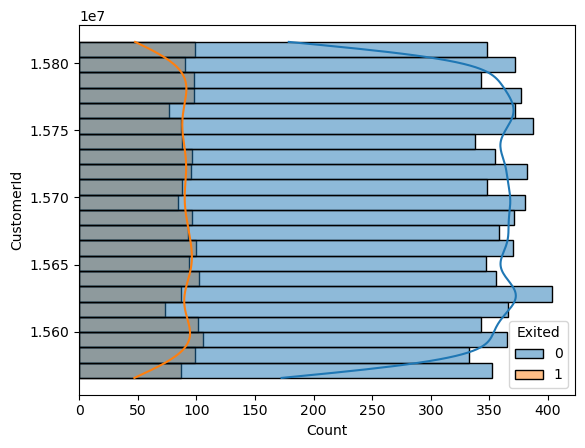

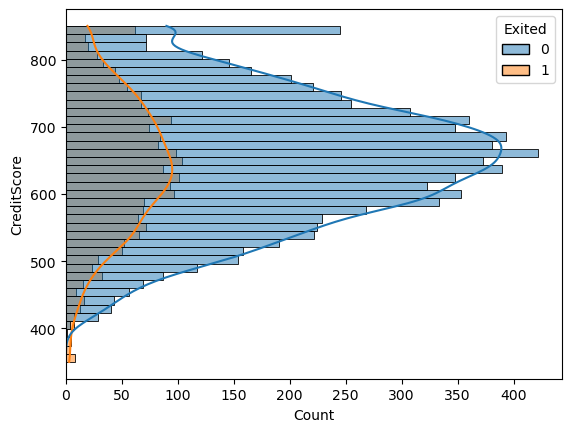

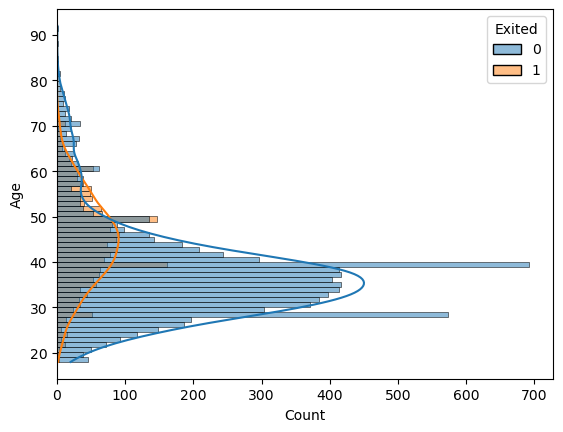

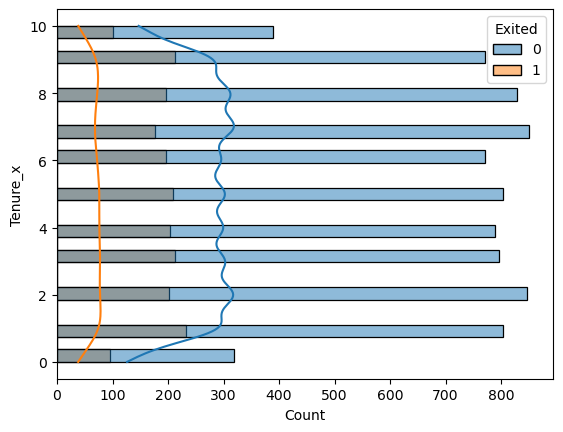

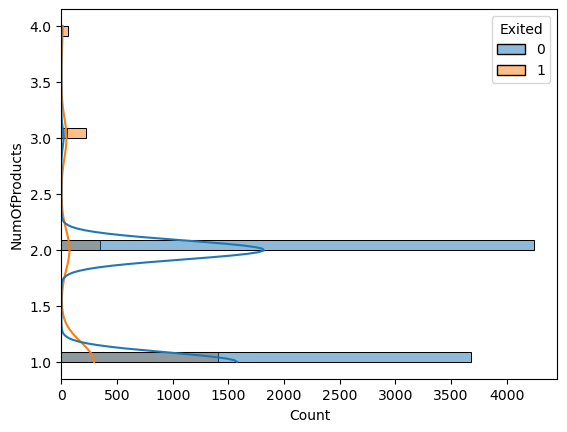

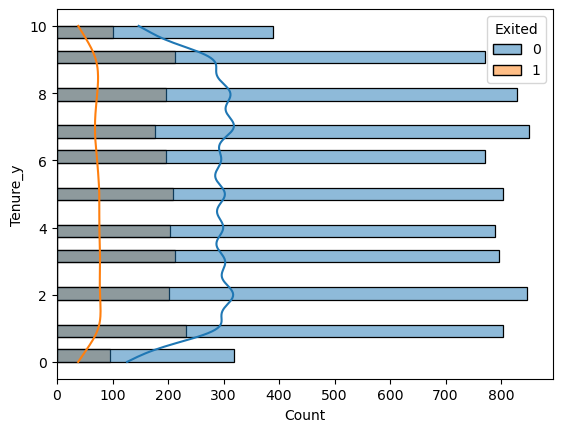

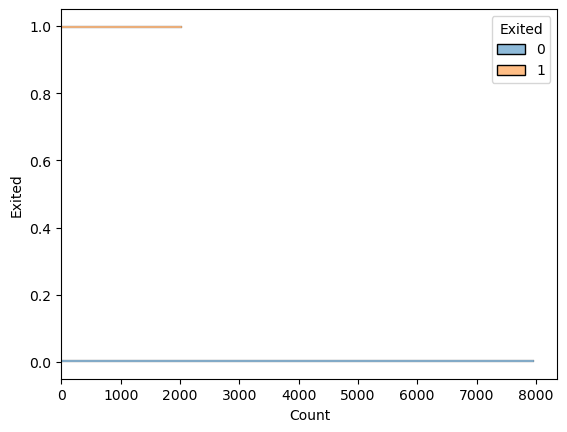

In [47]:
for col in churn_df.drop("Surname", axis=1).select_dtypes("number"):
    sns.histplot(data=churn_df, y=col, hue="Exited", kde=True)
    plt.show()

In [77]:
modeling_df=churn_df.drop(["CustomerId", "Surname"], axis=1)
modeling_df.head()

,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
0,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
1,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
2,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,1,Yes,0
3,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,8,No,1
4,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,1,No,0


In [78]:
modeling_df[["Balance", "EstimatedSalary"]].head()

,Balance,EstimatedSalary
0,€0.0,€101348.88
1,€0.0,€101348.88
2,€83807.86,€112542.58
3,€159660.8,€113931.57
4,€0.0,€93826.63


In [79]:
modeling_df["Balance"] = (
    modeling_df["Balance"]
    .astype(str)
    .str.replace("€", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

modeling_df["EstimatedSalary"] = (
    modeling_df["EstimatedSalary"]
    .astype(str)
    .str.replace("€", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

In [80]:
modeling_df["Balance_v_Sal"] = (
    modeling_df["Balance"] / modeling_df["EstimatedSalary"]
)

In [81]:
modeling_df["Balance_v_Sal"].describe()

count    10004.000000
mean         3.877887
std        108.315613
min         -0.141350
25%          0.000000
50%          0.746862
75%          1.515279
max      10614.655440
Name: Balance_v_Sal, dtype: float64

<Axes: ylabel='Balance_v_Sal'>

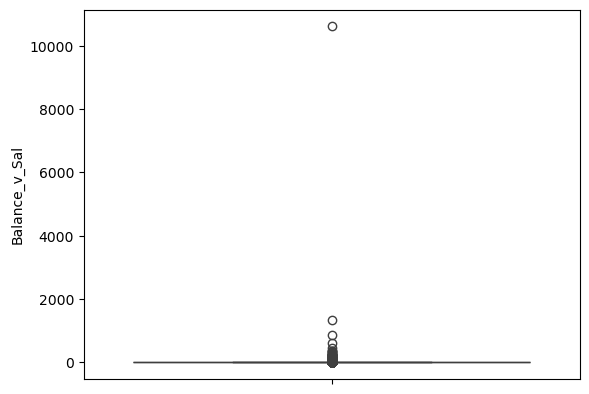

In [82]:
sns.boxplot(data=modeling_df, y="Balance_v_Sal")

In [49]:
pd.get_dummies(modeling_df, drop_first=True)

,CreditScore,Age,Tenure_x,NumOfProducts,Tenure_y,Exited,Geography_France,Geography_French,Geography_Germany,Geography_Spain,...,Balance_€99886.42,Balance_€99897.53,Balance_€99906.19,Balance_€99906.89,Balance_€99945.93,Balance_€99948.45,Balance_€99967.76,Balance_€99986.98,HasCrCard_Yes,IsActiveMember_Yes
0,619,42.0,2,1,2,1,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
1,619,42.0,2,1,2,1,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
2,608,41.0,1,1,1,0,False,False,False,True,...,False,False,False,False,False,False,False,False,True,True
3,502,42.0,8,3,8,1,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,699,39.0,1,2,1,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999,772,42.0,3,2,3,1,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
10000,792,28.0,4,1,4,0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
10001,792,28.0,4,1,4,0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
10002,792,28.0,4,1,4,0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [83]:
modeling_df[["Balance", "EstimatedSalary", "Balance_v_Sal"]].describe()

,Balance,EstimatedSalary,Balance_v_Sal
count,10004.000000,10004.000000,10004.000000
mean,76494.334391,99743.889855,3.877887
std,62396.534285,60581.133136,108.315613
min,0.000000,-999999.000000,-0.141350
25%,0.000000,50904.965000,0.000000
50%,97221.520000,100168.240000,0.746862
75%,127656.530000,149382.097500,1.515279
max,250898.090000,199992.480000,10614.655440


In [50]:
pd.get_dummies(modeling_df, drop_first=True)

,CreditScore,Age,Tenure_x,NumOfProducts,Tenure_y,Exited,Geography_France,Geography_French,Geography_Germany,Geography_Spain,...,Balance_€99886.42,Balance_€99897.53,Balance_€99906.19,Balance_€99906.89,Balance_€99945.93,Balance_€99948.45,Balance_€99967.76,Balance_€99986.98,HasCrCard_Yes,IsActiveMember_Yes
0,619,42.0,2,1,2,1,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
1,619,42.0,2,1,2,1,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
2,608,41.0,1,1,1,0,False,False,False,True,...,False,False,False,False,False,False,False,False,True,True
3,502,42.0,8,3,8,1,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,699,39.0,1,2,1,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9999,772,42.0,3,2,3,1,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
10000,792,28.0,4,1,4,0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
10001,792,28.0,4,1,4,0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
10002,792,28.0,4,1,4,0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [88]:
modeling_df[["Balance", "EstimatedSalary", "Balance_v_Sal"]].describe()

,Balance,EstimatedSalary,Balance_v_Sal
count,10004.000000,10004.000000,10004.000000
mean,76494.334391,99743.889855,3.877887
std,62396.534285,60581.133136,108.315613
min,0.000000,-999999.000000,-0.141350
25%,0.000000,50904.965000,0.000000
50%,97221.520000,100168.240000,0.746862
75%,127656.530000,149382.097500,1.515279
max,250898.090000,199992.480000,10614.655440


In [89]:
modeling_df[modeling_df["Balance"] < 0][["Balance", "EstimatedSalary"]].head()

,Balance,EstimatedSalary


In [91]:
modeling_df["Balance_v_Sal"] = modeling_df["Balance"] / modeling_df["EstimatedSalary"]
modeling_df.head()

,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited,Balance_v_Sal
0,619,FRA,Female,42.0,2,101348.88,0.00,1,Yes,2,Yes,1,0.000000
1,619,FRA,Female,42.0,2,101348.88,0.00,1,Yes,2,Yes,1,0.000000
2,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,1,Yes,0,0.744677
3,502,French,Female,42.0,8,113931.57,159660.80,3,No,8,No,1,1.401375
4,699,FRA,Female,39.0,1,93826.63,0.00,2,No,1,No,0,0.000000


<Axes: ylabel='Balance_v_Sal'>

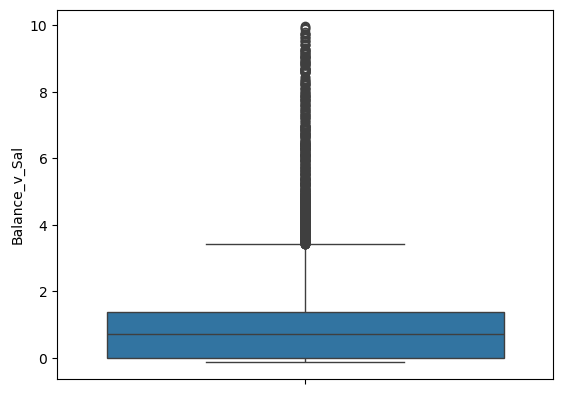

In [96]:
sns.boxplot(data=modeling_df.query("Balance_v_Sal < 10"), y="Balance_v_Sal")

In [93]:
modeling_df.describe()

,CreditScore,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,Tenure_y,Exited,Balance_v_Sal
count,10004.000000,10001.000000,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000
mean,650.568073,38.919108,5.012195,99743.889855,76494.334391,1.529988,5.012195,0.203719,3.877887
std,96.665531,10.488725,2.891806,60581.133136,62396.534285,0.581635,2.891806,0.402782,108.315613
min,350.000000,18.000000,0.000000,-999999.000000,0.000000,1.000000,0.000000,0.000000,-0.141350
25%,584.000000,32.000000,3.000000,50904.965000,0.000000,1.000000,3.000000,0.000000,0.000000
50%,652.000000,37.000000,5.000000,100168.240000,97221.520000,1.000000,5.000000,0.000000,0.746862
75%,718.000000,44.000000,7.000000,149382.097500,127656.530000,2.000000,7.000000,0.000000,1.515279
max,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,10.000000,1.000000,10614.655440


<Axes: ylabel='Balance_v_Sal'>

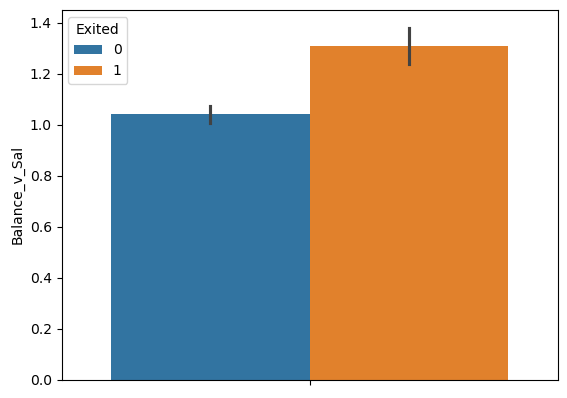

In [98]:
sns.barplot(data=modeling_df.query("Balance_v_Sal < 10"), y="Balance_v_Sal", hue="Exited")